In [1]:
import pandas as pd
import matplotlib.pyplot as plt

working_df = pd.read_csv("../data/processed/working_df.csv")

print("Shape:", working_df.shape)
working_df.head()

Shape: (116858, 11)


,gender,age,marital_status,education_level,formal_education_years,employment_status,industry,occupation,regular_earnings,self_employed_earnings,earnings
0,1,40,2,8,1,11,1.0,611.0,0,6500,6500
1,1,64,2,7,1,11,1.0,611.0,0,4500,4500
2,1,30,2,8,1,31,84.0,512.0,10000,0,10000
3,1,36,2,7,1,11,1.0,611.0,0,6500,6500
4,1,55,2,6,1,11,1.0,611.0,0,5000,5000


In [2]:
print("Education level distribution by gender:")
print(
    pd.crosstab(
        working_df["education_level"],
        working_df["gender"]
    )
)

Education level distribution by gender:
gender               1     2
education_level             
1                 8719  7180
2                   78    31
3                    0     3
4                   22    17
5                 3508  1801
6                 9710  4230
7                19494  6261
8                13032  3240
10               11282  2848
11                2115   509
12               13142  3903
13                3870  1863


In [3]:
print("\nEducation level percentages by gender:")
print(
    pd.crosstab(
        working_df["education_level"],
        working_df["gender"],
        normalize="columns"
    ).round(3) * 100
)


Education level percentages by gender:
gender              1     2
education_level            
1                10.3  22.5
2                 0.1   0.1
3                 0.0   0.0
4                 0.0   0.1
5                 4.1   5.6
6                11.4  13.3
7                22.9  19.6
8                15.3  10.2
10               13.3   8.9
11                2.5   1.6
12               15.5  12.2
13                4.6   5.8


In [4]:
education_earnings = (
    working_df
    .groupby(["education_level", "gender"])["earnings"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print(education_earnings)

                        count      mean   median
education_level gender                          
1               1        8719  12621.85  11000.0
                2        7180   5492.25   4100.0
2               1          78  13390.26  11500.0
                2          31   5995.16   4500.0
3               2           3   5216.67   6000.0
4               1          22  13758.68  12250.0
                2          17   5022.35   5200.0
5               1        3508  13728.69  12000.0
                2        1801   5836.24   5000.0
6               1        9710  14462.38  12800.0
                2        4230   6477.47   5000.0
7               1       19494  15856.77  14000.0
                2        6261   7088.42   5500.0
8               1       13032  17522.50  15000.0
                2        3240   7738.59   6000.0
10              1       11282  19693.87  15000.0
                2        2848  10208.41   7000.0
11              1        2115  24140.86  18000.0
                2   

In [5]:
median_education = (
    working_df
    .groupby(["education_level", "gender"])["earnings"]
    .median()
    .unstack()
)

median_education.columns = ["gender_1", "gender_2"]

median_education["difference"] = (
    median_education["gender_1"] -
    median_education["gender_2"]
)

print(median_education)

                 gender_1  gender_2  difference
education_level                                
1                 11000.0    4100.0      6900.0
2                 11500.0    4500.0      7000.0
3                     NaN    6000.0         NaN
4                 12250.0    5200.0      7050.0
5                 12000.0    5000.0      7000.0
6                 12800.0    5000.0      7800.0
7                 14000.0    5500.0      8500.0
8                 15000.0    6000.0      9000.0
10                15000.0    7000.0      8000.0
11                18000.0   13000.0      5000.0
12                25000.0   15000.0     10000.0
13                35000.0   27000.0      8000.0


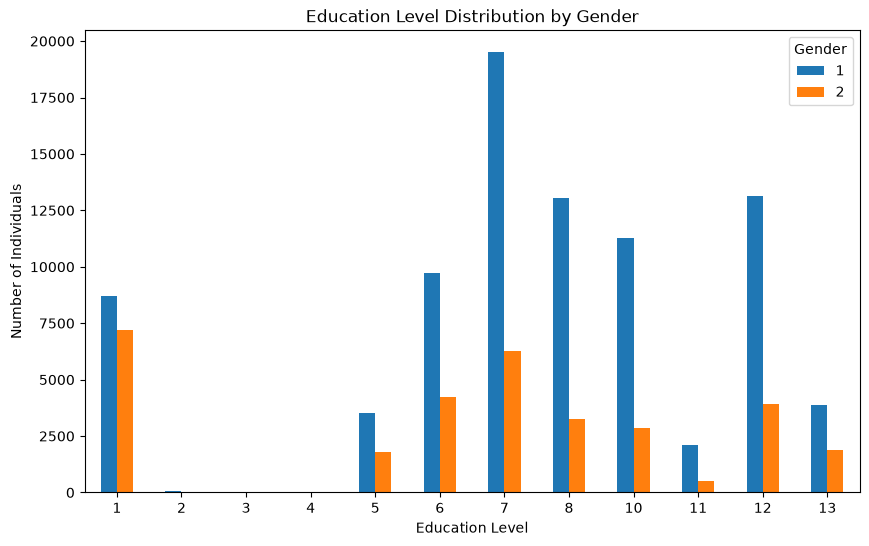

In [6]:
pd.crosstab(
    working_df["education_level"],
    working_df["gender"]
).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Education Level")
plt.ylabel("Number of Individuals")
plt.title("Education Level Distribution by Gender")
plt.legend(title="Gender")
plt.xticks(rotation=0)
plt.show()

In [7]:
employment_gender = (
    earners_df
    .groupby(["employment_status", "gender"])["earnings"]
    .median()
    .unstack()
)

employment_gender

NameError: name 'earners_df' is not defined

In [8]:
# Median earnings by employment status and gender

employment_gender = (
    earners_df
    .groupby(["employment_status", "gender"])["earnings"]
    .median()
    .unstack()
)

employment_gender.columns = ["gender_1", "gender_2"][:len(employment_gender.columns)]

employment_gender["difference"] = (
    employment_gender["gender_1"] - employment_gender["gender_2"]
)

employment_gender

NameError: name 'earners_df' is not defined

In [9]:
employment_gender = (
    earners_df
    .groupby(["employment_status", "gender"])["earnings"]
    .median()
    .unstack()
)

employment_gender

NameError: name 'earners_df' is not defined

In [10]:
# Recreate earnings column
analysis_df["earnings"] = (
    analysis_df["regular_earnings"] +
    analysis_df["self_employed_earnings"]
)

# Keep only people with positive earnings
earners_df = analysis_df[analysis_df["earnings"] > 0].copy()

print("Shape:", earners_df.shape)

NameError: name 'analysis_df' is not defined

In [11]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/perv1.csv")

print("Raw data shape:", df.shape)

Raw data shape: (418159, 139)


In [12]:
feature_mapping = {
    "gender": "b4q5_perv1",
    "age": "b4q6_perv1",
    "marital_status": "b4q7_perv1",
    "education_level": "b4q8_perv1",
    "formal_education_years": "b4q9_perv1",
    "employment_status": "b5pt1q3_perv1",
    "industry": "b5pt1q5_perv1",
    "occupation": "b5pt1q6_perv1",
    "regular_earnings": "b6q9_perv1",
    "self_employed_earnings": "b6q10_perv1"
}

analysis_df = df[list(feature_mapping.values())].copy()
analysis_df.columns = list(feature_mapping.keys())

print("Analysis dataframe shape:", analysis_df.shape)

Analysis dataframe shape: (418159, 10)


In [13]:
analysis_df["earnings"] = (
    analysis_df["regular_earnings"] +
    analysis_df["self_employed_earnings"]
)

earners_df = analysis_df[analysis_df["earnings"] > 0].copy()

print("Earner dataframe shape:", earners_df.shape)

Earner dataframe shape: (116859, 11)


In [14]:
employment_gender = (
    earners_df
    .groupby(["employment_status", "gender"])["earnings"]
    .median()
    .unstack()
)

employment_gender

gender,1,2,3
employment_status,,,
11,14000.0,5000.0,6000.0
12,25000.0,15000.0,NaN
21,8000.0,3540.0,NaN
31,15500.0,10000.0,NaN
41,7000.0,2500.0,NaN
51,6000.0,2930.0,NaN
81,8000.0,3500.0,NaN
91,6500.0,2500.0,NaN
92,3000.0,2500.0,NaN


In [15]:
employment_gender["Gap_Percentage"] = (
    (employment_gender[1] - employment_gender[2])
    / employment_gender[1]
) * 100

employment_gender

gender,1,2,3,Gap_Percentage
employment_status,,,,
11,14000.0,5000.0,6000.0,64.285714
12,25000.0,15000.0,NaN,40.000000
21,8000.0,3540.0,NaN,55.750000
31,15500.0,10000.0,NaN,35.483871
41,7000.0,2500.0,NaN,64.285714
51,6000.0,2930.0,NaN,51.166667
81,8000.0,3500.0,NaN,56.250000
91,6500.0,2500.0,NaN,61.538462
92,3000.0,2500.0,NaN,16.666667


In [16]:
# Top 15 occupations by number of earners

top_occupations = (
    earners_df["occupation"]
    .value_counts()
    .head(15)
)

top_occupations

occupation
611.0    18881
522.0    12287
832.0     5839
612.0     5567
112.0     3635
753.0     3479
613.0     3113
911.0     2740
541.0     2626
234.0     2336
932.0     2225
411.0     1815
731.0     1772
833.0     1751
723.0     1742
Name: count, dtype: int64

In [17]:
top_occ_codes = top_occupations.index

occupation_gender = (
    earners_df[earners_df["occupation"].isin(top_occ_codes)]
    .groupby(["occupation", "gender"])["earnings"]
    .median()
    .unstack()
)

occupation_gender

gender,1,2,3
occupation,,,
112.0,27000.0,10500.0,NaN
234.0,35000.0,12000.0,NaN
411.0,30000.0,30000.0,NaN
522.0,15000.0,9200.0,NaN
541.0,20000.0,29500.0,NaN
611.0,12000.0,6000.0,NaN
612.0,10000.0,4060.0,NaN
613.0,13000.0,6000.0,NaN
723.0,15000.0,19842.5,NaN


In [18]:
occupation_gender["Gap_Percentage"] = (
    (occupation_gender[1] - occupation_gender[2])
    / occupation_gender[1]
) * 100

occupation_gender

gender,1,2,3,Gap_Percentage
occupation,,,,
112.0,27000.0,10500.0,NaN,61.111111
234.0,35000.0,12000.0,NaN,65.714286
411.0,30000.0,30000.0,NaN,0.000000
522.0,15000.0,9200.0,NaN,38.666667
541.0,20000.0,29500.0,NaN,-47.500000
611.0,12000.0,6000.0,NaN,50.000000
612.0,10000.0,4060.0,NaN,59.400000
613.0,13000.0,6000.0,NaN,53.846154
723.0,15000.0,19842.5,NaN,-32.283333


In [19]:
top_industries = (
    earners_df["industry"]
    .value_counts()
    .head(15)
)

top_industries

industry
1124.0     6374
1412.0     3840
1111.0     3791
1500.0     3392
14105.0    2636
41001.0    2567
47211.0    2535
49224.0    2195
85102.0    2159
84119.0    1956
49231.0    1876
86100.0    1659
85211.0    1582
47711.0    1572
1139.0     1421
Name: count, dtype: int64

In [20]:
industry_gender = (
    earners_df[earners_df["industry"].isin(top_industries.index)]
    .groupby(["industry", "gender"])["earnings"]
    .median()
    .unstack()
)

industry_gender

gender,1,2,3
industry,,,
1111.0,11000.0,3500.0,NaN
1124.0,10000.0,4500.0,NaN
1139.0,11000.0,4500.0,NaN
1412.0,10000.0,4500.0,NaN
1500.0,12500.0,6000.0,NaN
14105.0,13000.0,5000.0,6000.0
41001.0,15500.0,9000.0,NaN
47211.0,15000.0,8500.0,NaN
47711.0,14500.0,10000.0,NaN


In [21]:
industry_gender["Gap_Percentage"] = (
    (industry_gender[1] - industry_gender[2])
    / industry_gender[1]
) * 100

industry_gender

gender,1,2,3,Gap_Percentage
industry,,,,
1111.0,11000.0,3500.0,NaN,68.181818
1124.0,10000.0,4500.0,NaN,55.000000
1139.0,11000.0,4500.0,NaN,59.090909
1412.0,10000.0,4500.0,NaN,55.000000
1500.0,12500.0,6000.0,NaN,52.000000
14105.0,13000.0,5000.0,6000.0,61.538462
41001.0,15500.0,9000.0,NaN,41.935484
47211.0,15000.0,8500.0,NaN,43.333333
47711.0,14500.0,10000.0,NaN,31.034483


In [22]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Copy the earnings dataset
feature_df = earners_df.copy()

# Features we want to test
features = [
    "gender",
    "age",
    "education_level",
    "formal_education_years",
    "employment_status",
    "industry",
    "occupation"
]

X = feature_df[features]
y = feature_df["earnings"]

# ANOVA F-test
f_scores, p_values = f_classif(X, y)

# Create results table
anova_results = pd.DataFrame({
    "Feature": features,
    "F_Score": f_scores,
    "P_Value": p_values
})

anova_results = anova_results.sort_values("F_Score", ascending=False)

anova_results

ValueError: Input X contains NaN.

In [23]:
# Check missing values in earners_df

print(earners_df[[
    "gender",
    "age",
    "education_level",
    "formal_education_years",
    "employment_status",
    "industry",
    "occupation",
    "earnings"
]].isnull().sum())

gender                       0
age                          0
education_level              0
formal_education_years       0
employment_status            0
industry                  4882
occupation                4882
earnings                     0
dtype: int64


In [24]:
# Prepare data for feature selection

feature_df = earners_df[[
    "gender",
    "age",
    "education_level",
    "formal_education_years",
    "employment_status",
    "industry",
    "occupation",
    "earnings"
]].copy()

print(feature_df.shape)
print(feature_df.isnull().sum())

(116859, 8)
gender                       0
age                          0
education_level              0
formal_education_years       0
employment_status            0
industry                  4882
occupation                4882
earnings                     0
dtype: int64


In [25]:
# Remove rows with missing industry or occupation
feature_df = earners_df.dropna(
    subset=["industry", "occupation"]
).copy()

print("Shape:", feature_df.shape)
print(feature_df.isnull().sum())

Shape: (111977, 11)
gender                    0
age                       0
marital_status            0
education_level           0
formal_education_years    0
employment_status         0
industry                  0
occupation                0
regular_earnings          0
self_employed_earnings    0
earnings                  0
dtype: int64


In [26]:
from sklearn.feature_selection import mutual_info_regression

# Features and target
features = [
    "gender",
    "age",
    "education_level",
    "formal_education_years",
    "employment_status",
    "industry",
    "occupation"
]

X = feature_df[features]
y = feature_df["earnings"]

# Calculate mutual information
mi_scores = mutual_info_regression(
    X,
    y,
    random_state=42
)

# Create results table
mi_results = pd.DataFrame({
    "Feature": features,
    "MI_Score": mi_scores
})

# Sort from strongest to weakest
mi_results = mi_results.sort_values(
    "MI_Score",
    ascending=False
)

mi_results

,Feature,MI_Score
5,industry,0.310860
6,occupation,0.307890
2,education_level,0.129795
0,gender,0.113861
4,employment_status,0.089438
1,age,0.039082
3,formal_education_years,0.038717


In [27]:
age_gender = (
    earners_df
    .groupby(["age", "gender"])["earnings"]
    .median()
    .unstack()
)

age_gender.columns = ["Gender_1", "Gender_2", "Gender_3"]

age_gender.head(20)

,Gender_1,Gender_2,Gender_3
age,,,
11,2000.0,525.0,NaN
12,5000.0,900.0,NaN
13,3000.0,1800.0,NaN
14,3000.0,5000.0,NaN
15,5000.0,3600.0,NaN
16,6000.0,3000.0,NaN
17,8000.0,4500.0,NaN
18,8000.0,4000.0,NaN
19,9500.0,4800.0,NaN


In [28]:
age_gender["Gap_Percentage"] = (
    (age_gender["Gender_1"] - age_gender["Gender_2"])
    / age_gender["Gender_1"]
) * 100

age_gender.head(20)

,Gender_1,Gender_2,Gender_3,Gap_Percentage
age,,,,
11,2000.0,525.0,NaN,73.750000
12,5000.0,900.0,NaN,82.000000
13,3000.0,1800.0,NaN,40.000000
14,3000.0,5000.0,NaN,-66.666667
15,5000.0,3600.0,NaN,28.000000
16,6000.0,3000.0,NaN,50.000000
17,8000.0,4500.0,NaN,43.750000
18,8000.0,4000.0,NaN,50.000000
19,9500.0,4800.0,NaN,49.473684


In [29]:
# Create age groups
age_gender_df = earners_df.copy()

age_gender_df["age_group"] = pd.cut(
    age_gender_df["age"],
    bins=[10, 20, 30, 40, 50, 60, 70, 100],
    labels=[
        "11-20",
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71+"
    ]
)

# Median earnings by age group and gender
age_group_earnings = (
    age_gender_df
    .groupby(["age_group", "gender"], observed=True)["earnings"]
    .median()
    .unstack()
)

age_group_earnings.columns = [
    f"Gender_{col}" for col in age_group_earnings.columns
]

age_group_earnings

,Gender_1,Gender_2,Gender_3
age_group,,,
11-20,9000.0,4500.0,NaN
21-30,14000.0,7000.0,NaN
31-40,16000.0,6500.0,6000.0
41-50,16000.0,6000.0,NaN
51-60,15000.0,5500.0,NaN
61-70,11000.0,4300.0,NaN
71+,8500.0,4000.0,NaN


In [30]:
age_group_earnings["Gap_Percentage"] = (
    (age_group_earnings["Gender_1"] - age_group_earnings["Gender_2"])
    / age_group_earnings["Gender_1"]
) * 100

age_group_earnings

,Gender_1,Gender_2,Gender_3,Gap_Percentage
age_group,,,,
11-20,9000.0,4500.0,NaN,50.000000
21-30,14000.0,7000.0,NaN,50.000000
31-40,16000.0,6500.0,6000.0,59.375000
41-50,16000.0,6000.0,NaN,62.500000
51-60,15000.0,5500.0,NaN,63.333333
61-70,11000.0,4300.0,NaN,60.909091
71+,8500.0,4000.0,NaN,52.941176


In [31]:
age_group_counts = (
    age_gender_df
    .groupby(["age_group", "gender"], observed=True)
    .size()
    .unstack(fill_value=0)
)

age_group_counts.columns = [
    f"Gender_{col}" for col in age_group_counts.columns
]

age_group_counts

,Gender_1,Gender_2,Gender_3
age_group,,,
11-20,2101,778,0
21-30,17407,6297,0
31-40,22787,10123,1
41-50,21345,8465,0
51-60,14226,4545,0
61-70,6049,1469,0
71+,1057,209,0


In [ ]:
import os

os.makedirs("../data/processed", exist_ok=True)

final_eda_df = earners_df.copy()

final_eda_df.to_csv(
    "../data/processed/salary_analysis_ready.csv",
    index=False
)

print("Saved!")
print("Shape:", final_eda_df.shape)``

Saved!
Shape: (116859, 11)
